In [1]:

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Accidents Dataset") \
    .getOrCreate()

df = spark.read.option("header", True).csv(
    "hdfs://namenode:9000/user/gyembo/project/traffic_cleaned_eda_csv"
)
df.show(5)
df.printSchema()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/29 10:26:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/29 10:26:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+--------------------+--------------------+------------------+----------+------------+----------+---------+-----+-------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+--------+--------+-------+-------+-----+--------------+--------------+----+-----+---------+----+------------------+
|Severity|          Start_Time|            End_Time|         Start_Lat| Start_Lng|Distance(mi)|      City|   County|State|Country|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Weather_Condition|Amenity|Crossing|Junction|Railway|Station| Stop|Traffic_Signal|Sunrise_Sunset|Hour|Month|DayOfWeek|Year|  Duration_Minutes|
+--------+--------------------+--------------------+------------------+----------+------------+----------+---------+-----+-------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+--------+--------+-------+-------+-----+--

In [7]:

#PALETTE & HELPERS

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
import numpy as np

PALETTE = {
    "bg":      "#0d1117",
    "panel":   "#161b22",
    "accent1": "#58a6ff",
    "accent2": "#3fb950",
    "accent3": "#f78166",
    "accent4": "#d29922",
    "accent5": "#bc8cff",
    "text":    "#e6edf3",
    "grid":    "#21262d",
}

SEV_COLORS = {
    1: PALETTE["accent2"],
    2: PALETTE["accent1"],
    3: PALETTE["accent4"],
    4: PALETTE["accent3"]
}

CAT_CMAP = [
    PALETTE["accent1"], PALETTE["accent5"], PALETTE["accent2"],
    PALETTE["accent4"], PALETTE["accent3"],
    "#79c0ff", "#56d364", "#ffa657", "#ff7b72", "#cae8ff"
]

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor":   PALETTE["panel"],
    "axes.edgecolor":   PALETTE["grid"],
    "axes.labelcolor":  PALETTE["text"],
    "xtick.color":      PALETTE["text"],
    "ytick.color":      PALETTE["text"],
    "text.color":       PALETTE["text"],
    "grid.color":       PALETTE["grid"],
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.titlepad":    12,
})

def style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.4)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ax

def fmt_y(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"
    ))

def save(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png", dpi=120,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()

DOW_MAP   = {1:"Monday", 2:"Tuesday", 3:"Wednesday",
             4:"Thursday", 5:"Friday", 6:"Saturday", 7:"Sunday"}
DOW_ORDER = ["Monday","Tuesday","Wednesday",
             "Thursday","Friday","Saturday","Sunday"]
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

print("All helpers ready — now run your plot cells")

All helpers ready — now run your plot cells


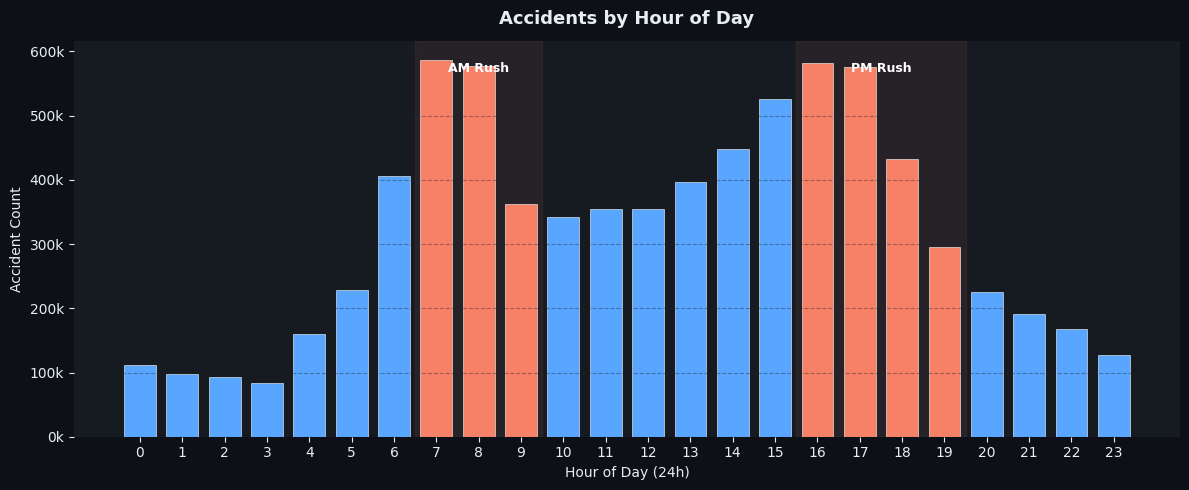

In [ ]:
# Accident by Hour of Day

hour_pd = (
    df.groupBy("Hour").count()
      .orderBy("Hour")
      .toPandas()
)
hour_pd["Hour"] = hour_pd["Hour"].astype(int)
hour_pd = hour_pd.sort_values("Hour").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))

colors = [PALETTE["accent3"] if h in list(range(7, 10)) + list(range(16, 20))
          else PALETTE["accent1"] for h in hour_pd["Hour"]]

# ── ax.bar() — no seaborn, no warnings ──
ax.bar(hour_pd["Hour"], hour_pd["count"],
       color=colors, edgecolor="white",
       linewidth=0.4, width=0.75)

for span, label in [((7, 9), "AM Rush"), ((16, 19), "PM Rush")]:
    ax.axvspan(span[0] - 0.5, span[1] + 0.5,
               alpha=0.08, color=PALETTE["accent3"], zorder=0)
    ax.text((span[0] + span[1]) / 2, ax.get_ylim()[1] * 0.92,
            label, ha="center", fontsize=9,
            color="white", fontweight="bold")

ax.set_xticks(range(0, 24))
ax.set_xticklabels(range(0, 24))
fmt_y(ax)
style_ax(ax,
         title="Accidents by Hour of Day",
         xlabel="Hour of Day (24h)",
         ylabel="Accident Count")
save("temp_01_hourly")

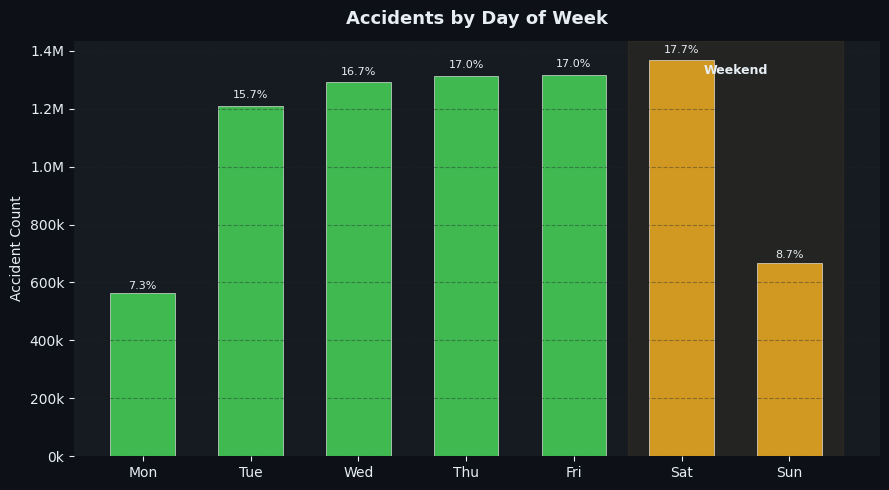

In [ ]:
# Accident by Day of Week
dow_pd = (
    df.groupBy("DayOfWeek").count()
      .orderBy("DayOfWeek")
      .toPandas()
)
dow_pd["DayOfWeek"] = dow_pd["DayOfWeek"].astype(int).map(DOW_MAP)
dow_pd = dow_pd.set_index("DayOfWeek").reindex(DOW_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

colors = [PALETTE["accent4"] if d in ["Saturday", "Sunday"]
          else PALETTE["accent2"] for d in dow_pd["DayOfWeek"]]

ax.bar(range(len(DOW_ORDER)), dow_pd["count"],
       color=colors, edgecolor="white",
       linewidth=0.4, width=0.6)

total = dow_pd["count"].sum()
for i, val in enumerate(dow_pd["count"]):
    ax.text(i, val * 1.015,
            f"{val/total*100:.1f}%",
            ha="center", va="bottom",
            fontsize=8, color=PALETTE["text"])

ax.axvspan(4.5, 6.5, alpha=0.08, color=PALETTE["accent4"], zorder=0)
ax.text(5.5, ax.get_ylim()[1] * 0.92,                                                                                           
        "Weekend", ha="center", fontsize=9,
        color=PALETTE["text"], fontweight="bold")

ax.set_xticks(range(len(DOW_ORDER)))
ax.set_xticklabels([d[:3] for d in DOW_ORDER])
fmt_y(ax)
style_ax(ax,
         title="Accidents by Day of Week",
         xlabel="",
         ylabel="Accident Count")
save("temp_02_dow")

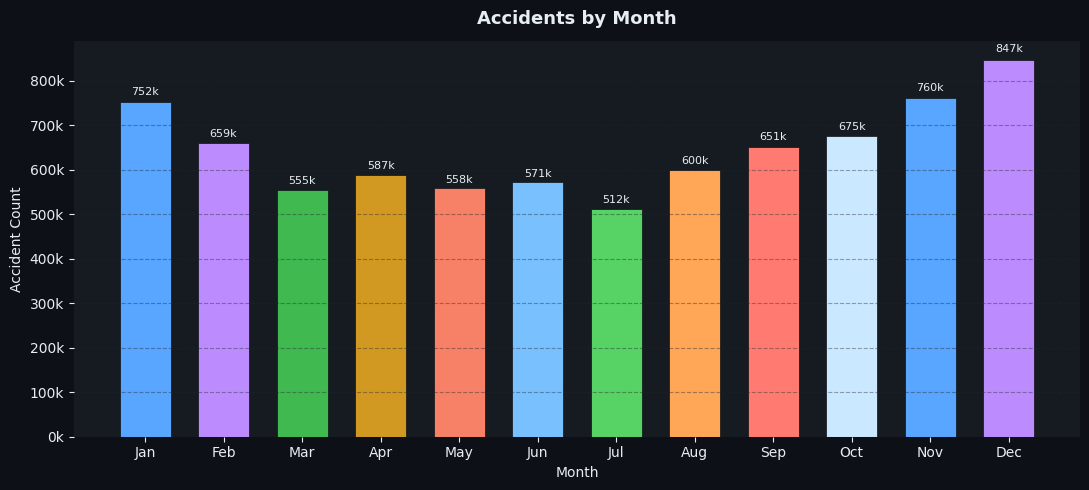

In [ ]:
#Accident by Month
month_pd = (
    df.groupBy("Month").count()
      .orderBy("Month")
      .toPandas()
)
month_pd["Month"]       = month_pd["Month"].astype(int)
month_pd                = month_pd.sort_values("Month").reset_index(drop=True)
month_pd["month_label"] = month_pd["Month"].apply(
    lambda x: MONTH_LABELS[x - 1]
)


colors = CAT_CMAP[:len(month_pd)]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    range(len(month_pd)), month_pd["count"],
    color=colors, edgecolor=PALETTE["bg"],
    linewidth=0.5, width=0.65
)


for bar, val in zip(bars, month_pd["count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.015,
        f"{val/1e3:.0f}k",
        ha="center", va="bottom",
        fontsize=8, color=PALETTE["text"]
    )

ax.set_xticks(range(len(month_pd)))
ax.set_xticklabels(month_pd["month_label"])
fmt_y(ax)
style_ax(ax,
         title="Accidents by Month",
         xlabel="Month",
         ylabel="Accident Count")
save("temp_03_monthly")

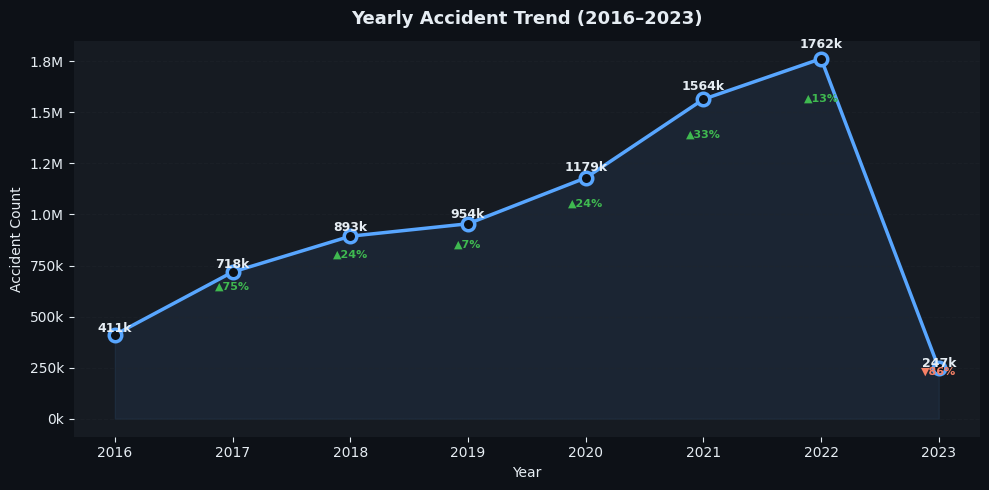

In [ ]:
# Yearly accident trend
year_pd = (
    df.groupBy("Year").count()
      .orderBy("Year")
      .toPandas()
)
year_pd["Year"]  = year_pd["Year"].astype(int)
year_pd["count"] = year_pd["count"].astype(int)
year_pd = year_pd[year_pd["Year"].between(2016, 2023)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(year_pd["Year"], year_pd["count"],
        color=PALETTE["accent1"], linewidth=2.5,
        marker="o", markersize=9,
        markerfacecolor=PALETTE["bg"],
        markeredgecolor=PALETTE["accent1"],
        markeredgewidth=2.5, zorder=3)

ax.fill_between(year_pd["Year"], year_pd["count"],
                color=PALETTE["accent1"], alpha=0.08)


for _, row in year_pd.iterrows():
    ax.text(row["Year"], row["count"] * 1.03,
            f"{row['count']/1e3:.0f}k",
            ha="center", fontsize=9,
            color=PALETTE["text"], fontweight="bold")


for i in range(1, len(year_pd)):
    prev = year_pd.loc[i-1, "count"]
    curr = year_pd.loc[i,   "count"]
    pct  = (curr - prev) / prev * 100
    ax.text(year_pd.loc[i, "Year"],
            year_pd.loc[i, "count"] * 0.88,
            f"{'▲' if pct > 0 else '▼'}{abs(pct):.0f}%",
            ha="center", fontsize=8, fontweight="bold",
            color=PALETTE["accent2"] if pct > 0 else PALETTE["accent3"])

ax.set_xticks(year_pd["Year"])
fmt_y(ax)
style_ax(ax,
         title="Yearly Accident Trend (2016–2023)",
         xlabel="Year",
         ylabel="Accident Count")
save("temp_04_yearly")